In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS
from analysis.plot_batch import (
    plot_batch_metric_violins,
    analyze_batch_statistics,
    check_batch_classification_power,
    check_discrete_covariate_batch_effects,
    plot_covariate_auc_heatmap,
    plot_covariate_auc_violins,
)
from viz_style import apply_style
apply_style()

In [3]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]

combined_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "NP80", "(NP80/NG80)",
    "Sample Volume (mL)", "Total Centrifugation Force (g)",
]

### Bias ~ Batch Relationship

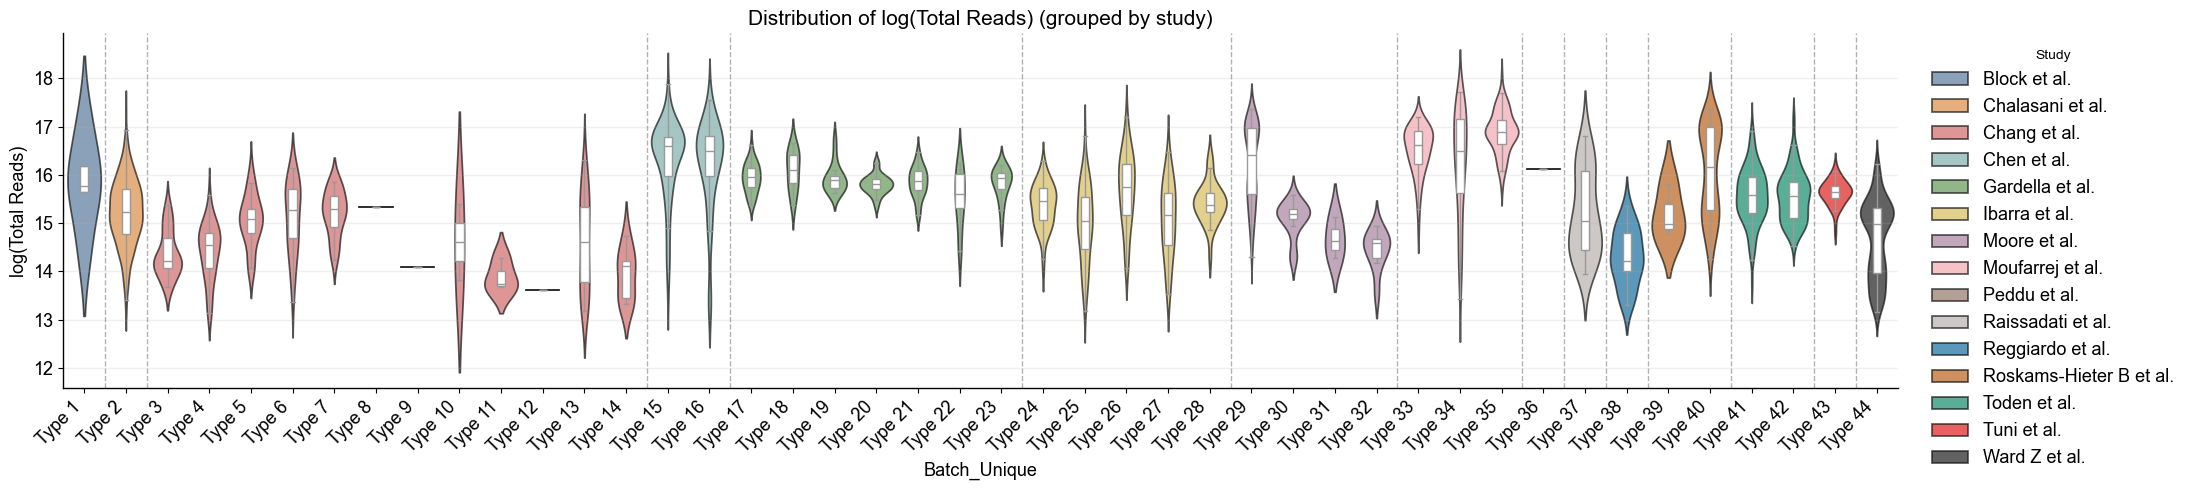

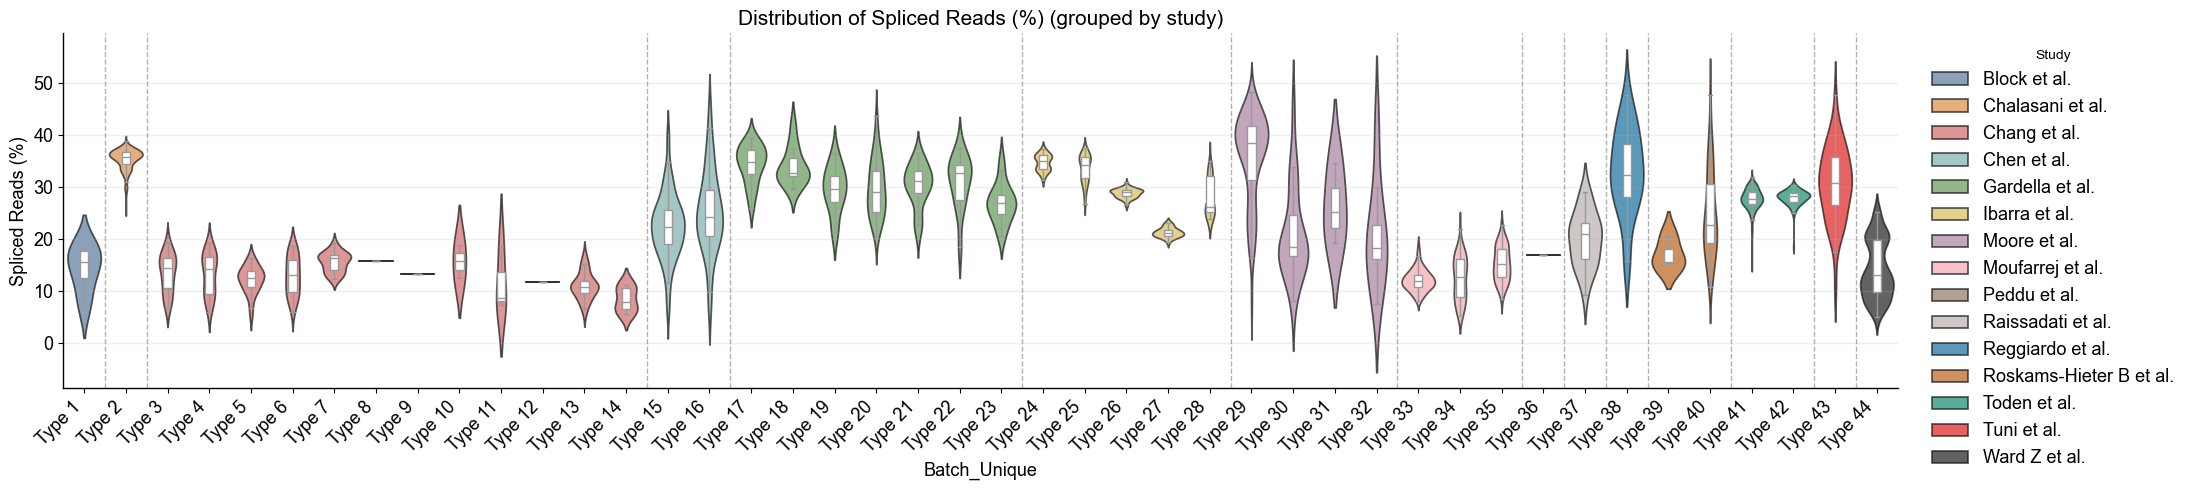

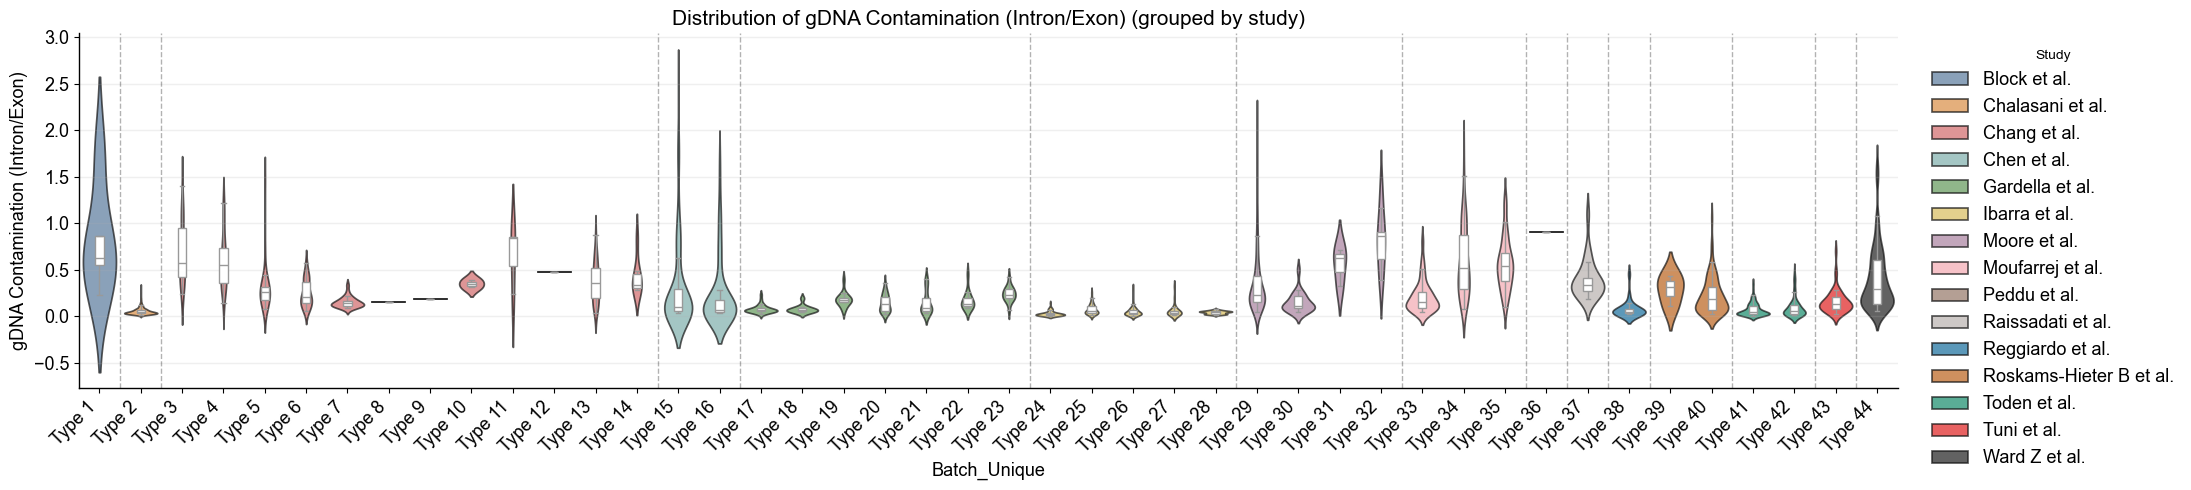

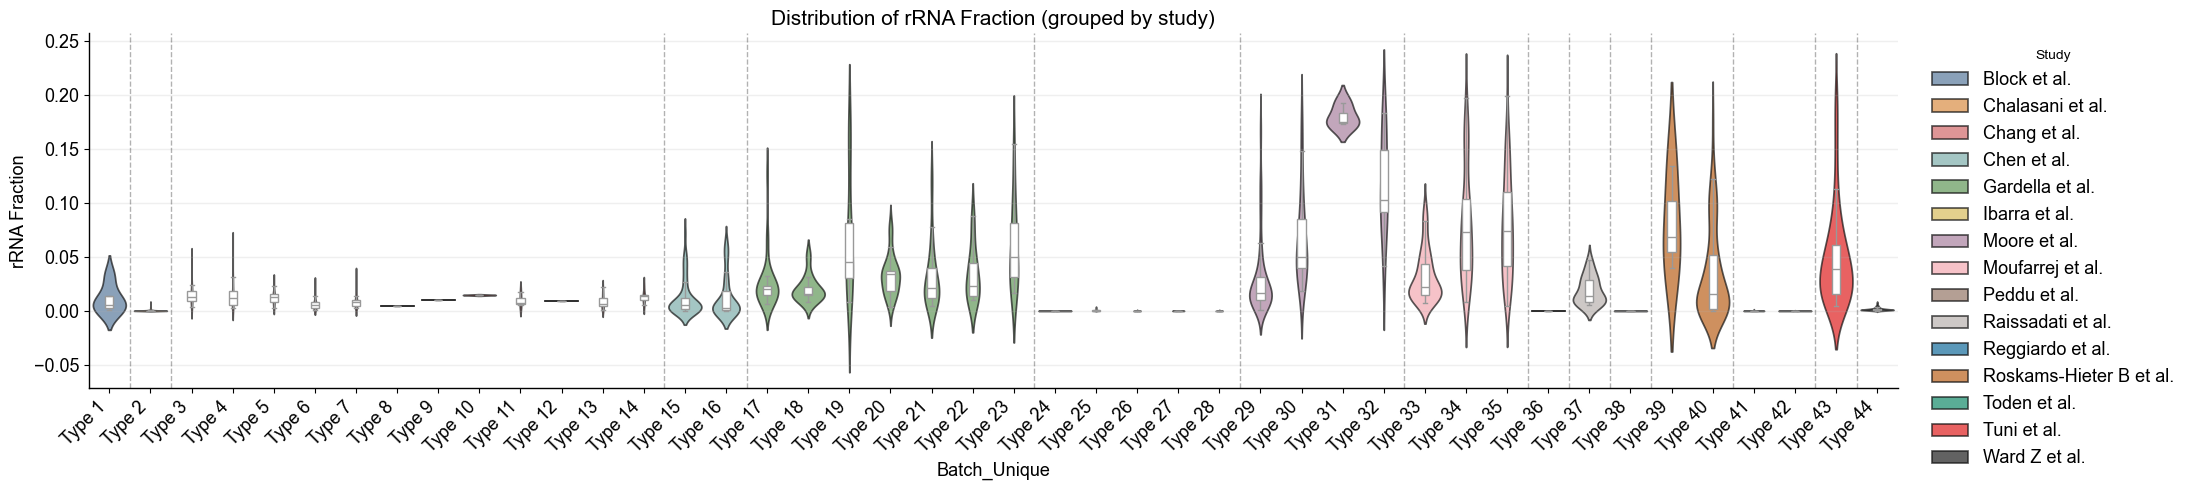

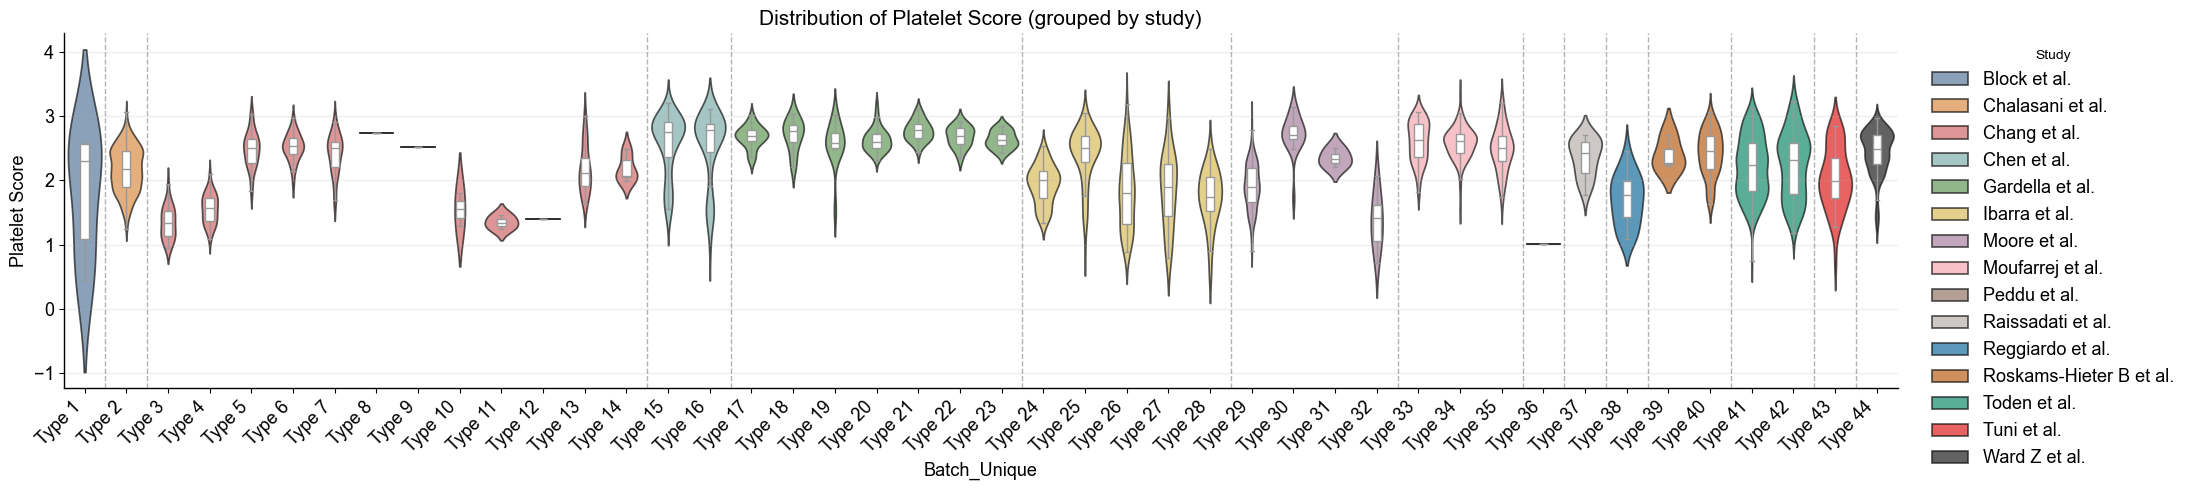

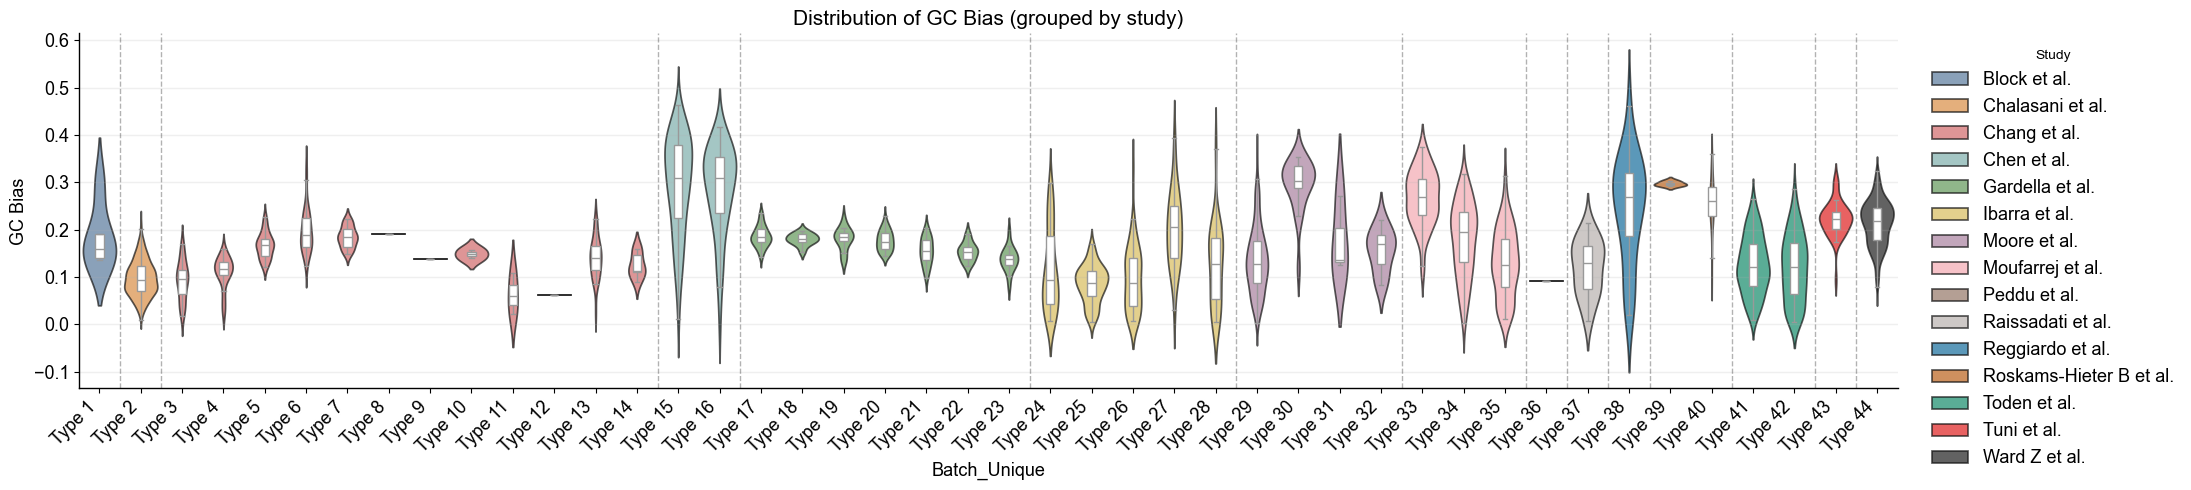

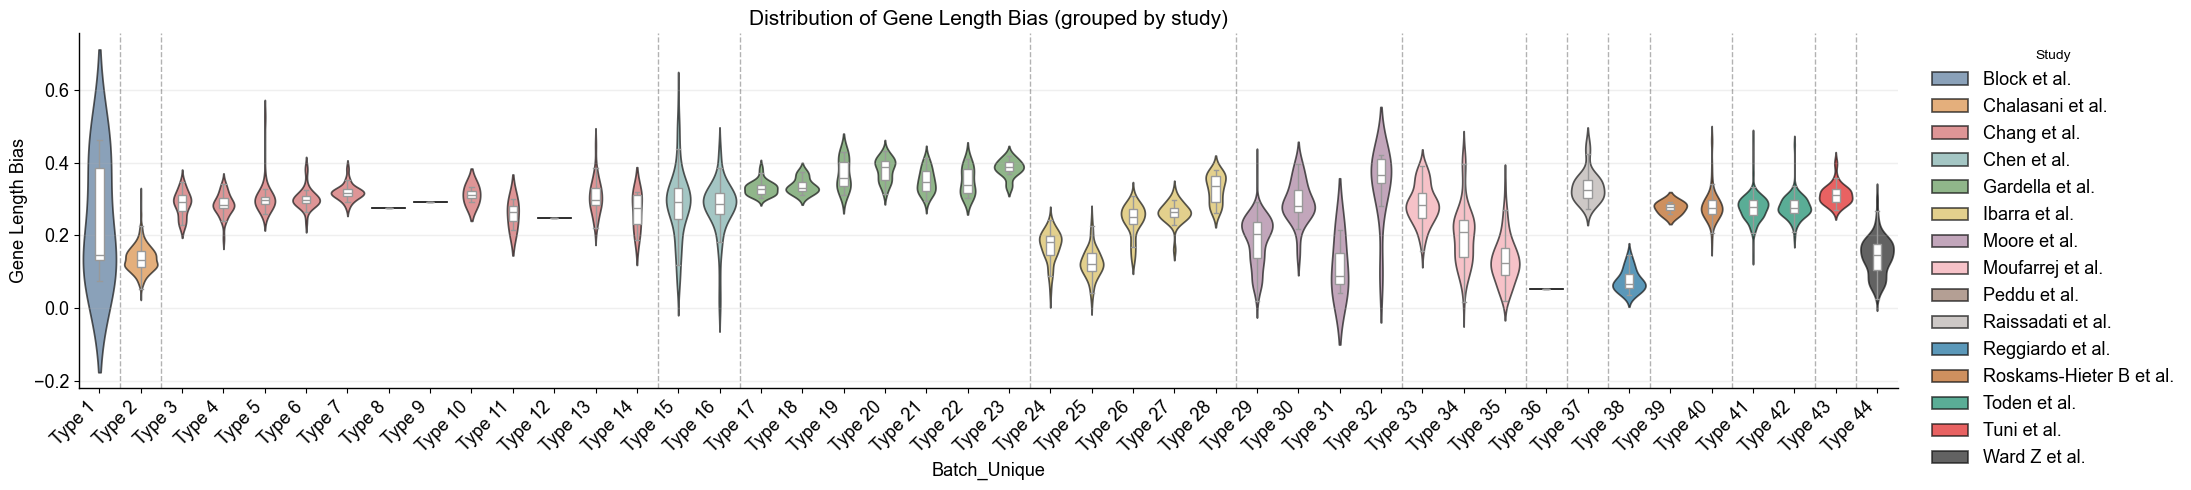

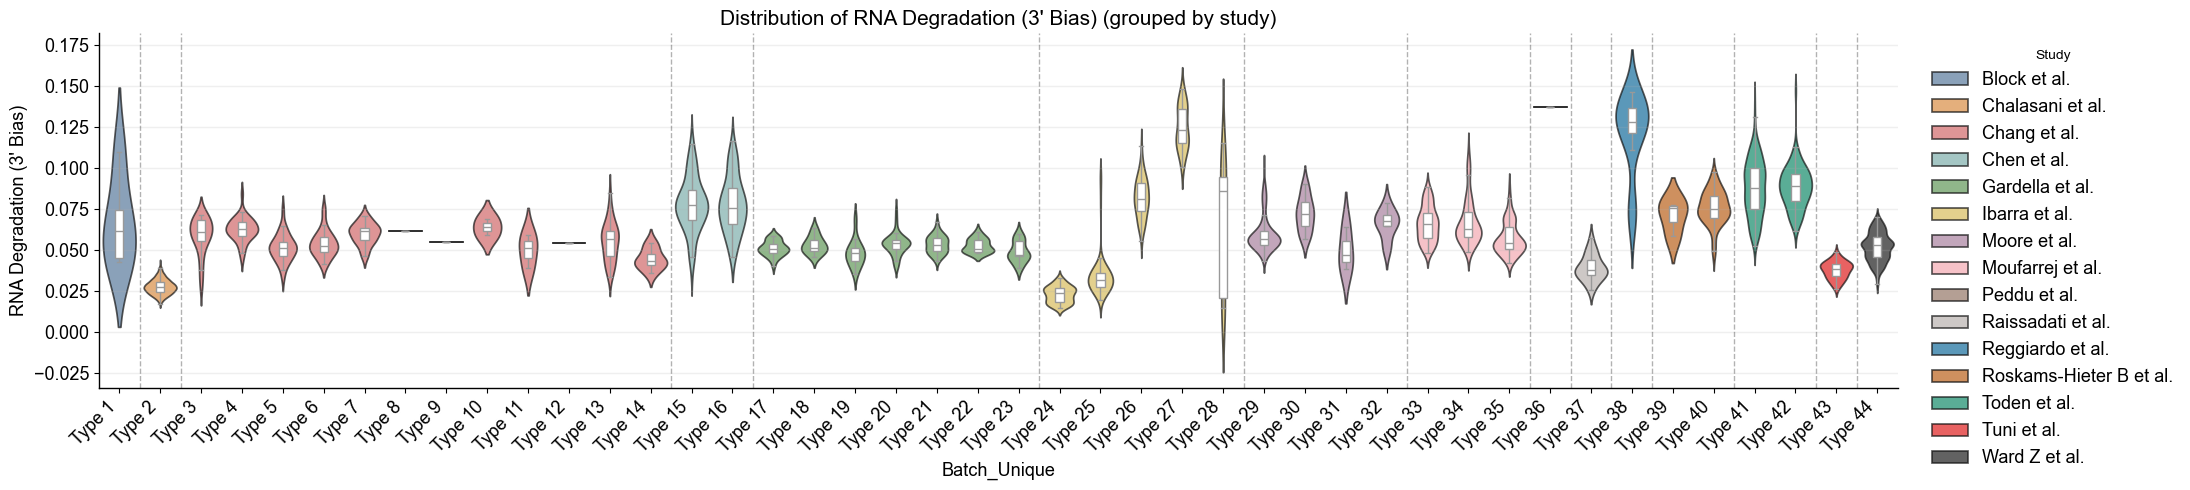

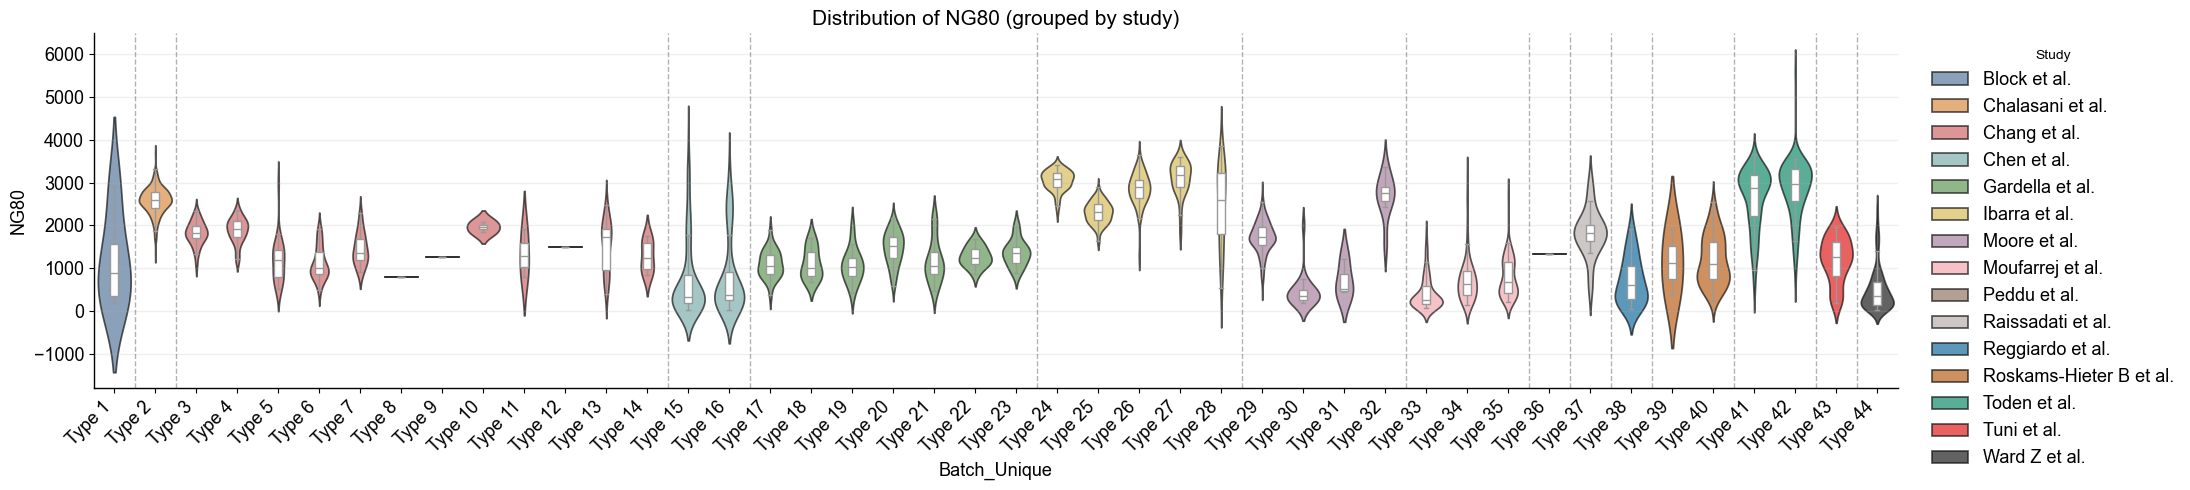

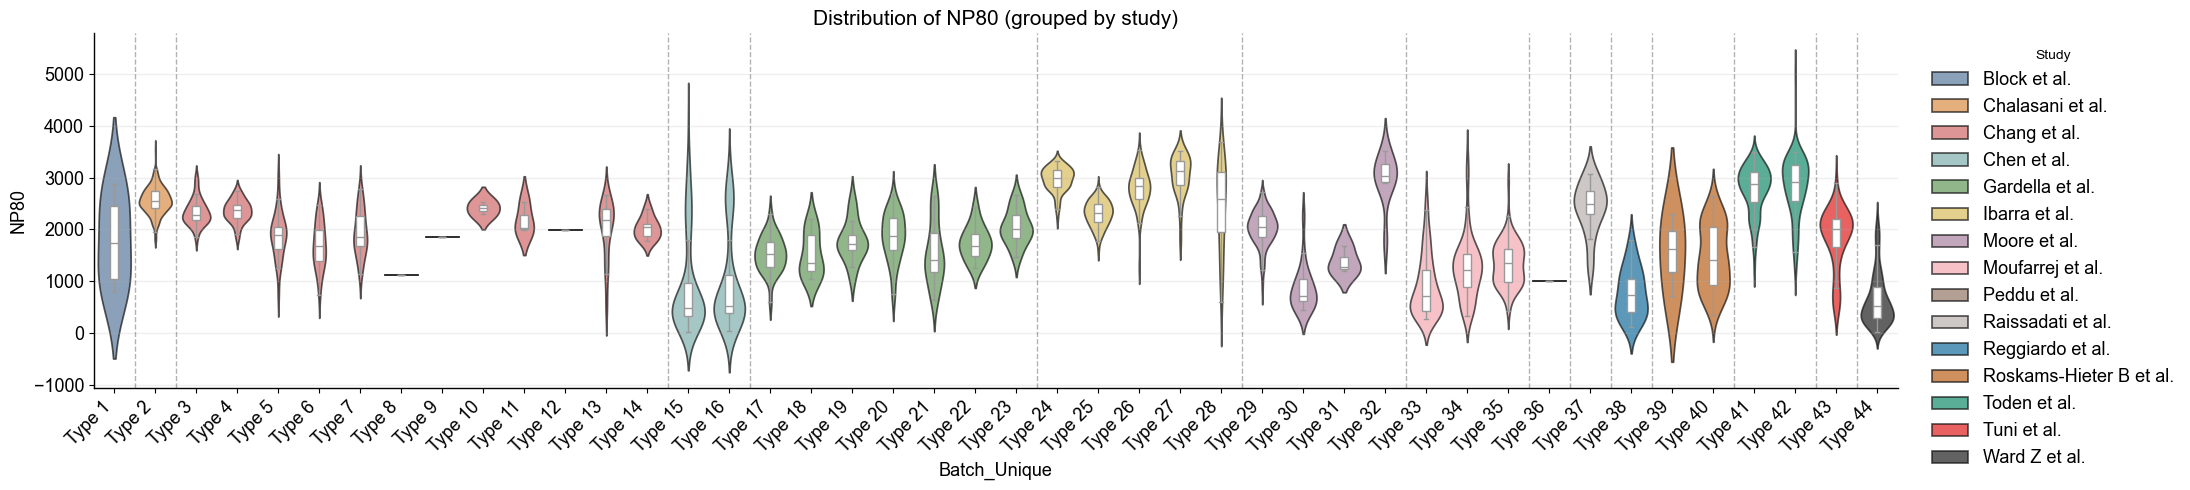

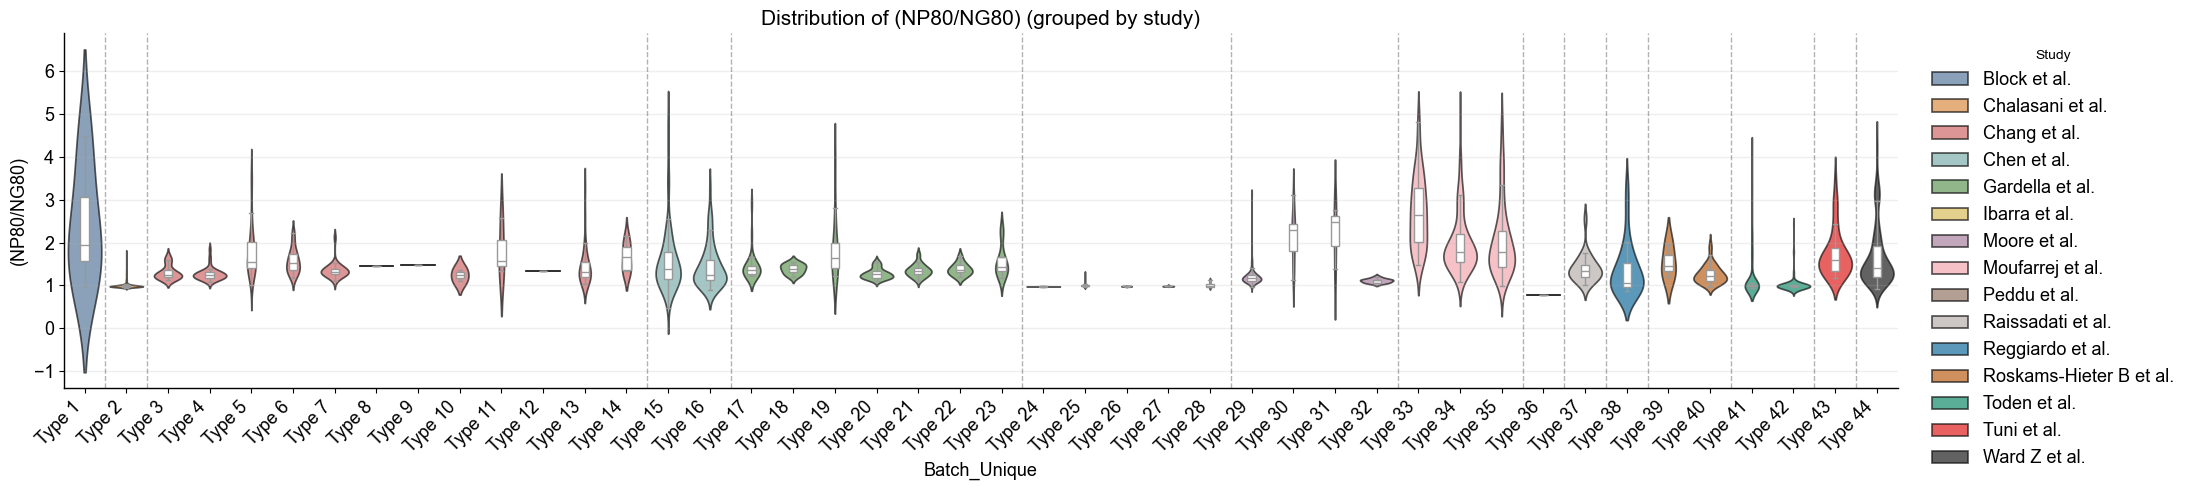


### Batch Effect Statistics ###
                              Metric     H-stat  p-value  Eta_Sq
7          RNA Degradation (3' Bias)  2677.3270      0.0  0.8323
3                      rRNA Fraction  2581.9050      0.0  0.8022
1                  Spliced Reads (%)  2417.4491      0.0  0.7502
8                               NG80  2391.8432      0.0  0.7421
6                   Gene Length Bias  2228.0239      0.0  0.6904
9                               NP80  2224.0795      0.0  0.6891
10                       (NP80/NG80)  2164.2916      0.0  0.6702
2   gDNA Contamination (Intron/Exon)  1944.4375      0.0  0.6008
5                            GC Bias  1627.8313      0.0  0.5007
0                   log(Total Reads)  1267.3711      0.0  0.3868
4                     Platelet Score  1062.3739      0.0  0.3221



[PERMANOVA] Pseudo-F: 109.4810, p=0.0010


In [4]:
from scipy.stats import zscore

df_obs = adata.obs.copy().sort_values(["Author", "Batch_ID"])
bias_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "Platelet Score", "GC Bias", "Gene Length Bias",
    "RNA Degradation (3' Bias)", "NG80", "NP80", "(NP80/NG80)",
]
ordered_batches = df_obs["Batch_ID"].unique()
df_obs["Batch_Unique"] = pd.Categorical(df_obs["Batch_ID"], categories=ordered_batches, ordered=True)

batch_info = df_obs.groupby("Batch_ID", sort=False, observed=True)["Author"].first()
author_change_indices = np.where(batch_info.values[:-1] != batch_info.values[1:])[0] + 0.5
batch_type_dict = {b: f"Type {i+1}" for i, b in enumerate(ordered_batches)}

plot_batch_metric_violins(
    df_obs, bias_metrics, batch_col="Batch_Unique", author_col="Author",
    author_change_indices=author_change_indices, batch_type_dict=batch_type_dict,
    save_path=None  # was "./Analysis_Results/BiasBatch/batch_metric_violins/dist"
)
df_kw, permanova_res = analyze_batch_statistics(df_obs, bias_metrics, "Batch_Unique")

In [5]:
# df_kw.to_csv("./Analysis_Results/BiasBatch/batch_metric_violins/kruskal_wallis_results.tsv", sep='\t')

In [6]:
# permanova_res.to_csv("./Analysis_Results/BiasBatch/batch_metric_violins/permanova_results.tsv", sep='\t')

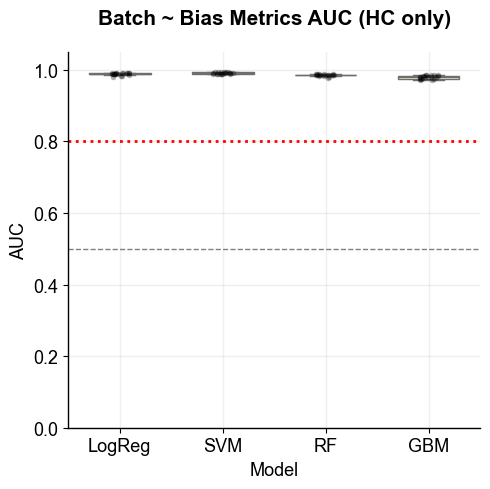

In [7]:
batch_pred_res = check_batch_classification_power(adata, bias_metrics, target_col="Author")

my_pal = {"LogReg": "#A8D8EA", "SVM": "#AA96DA", "RF": "#FCBAD3", "GBM": "#FFFFD2"}
plt.figure(figsize=(5, 5))
sns.boxplot(data=batch_pred_res, x="Model", y="AUC", hue="Model",
            palette=my_pal, showfliers=False, width=0.6, legend=False)
sns.stripplot(data=batch_pred_res, x="Model", y="AUC",
              color="black", alpha=0.3, jitter=True, size=4)
plt.axhline(0.5, color="gray", linestyle="--", label="Random Chance (0.5)")
plt.axhline(0.8, color="red", linestyle=":", linewidth=2)
plt.title("Batch ~ Bias Metrics AUC (HC only)", fontweight="bold", pad=20)
plt.ylabel("AUC")
plt.ylim(0, 1.05)
plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig("./Analysis_Results/BiasBatch/batch_classification_auc.png", bbox_inches='tight')
plt.show()

Running discrete covariate AUC evaluation (HC only, batch-disjoint splits) ...
  [Drop] instrument: classes confined to <2 batches or too few samples: ['Ilumina HiSeq X Ten', 'Illumina NextSeq 2000', 'Illumina HiSeq X Ten']


  instrument                                   : n_classes= 5  n= 799  n_batches=32  folds=20  mean_AUC=0.900
  [Drop] rna_extraction_kit_short_name: classes confined to <2 batches or too few samples: ['MOF', 'Promega', 'Qiagen ExoRNeasy']


  rna_extraction_kit_short_name                : n_classes= 3  n= 813  n_batches=32  folds=20  mean_AUC=0.975


  plasma_tubes_short_name                      : n_classes= 5  n= 996  n_batches=35  folds=15  mean_AUC=0.969
  [Drop] library_prep_kit_short_name: classes confined to <2 batches or too few samples: ['SMARTer Pico v1', 'SMART-Seq']


  library_prep_kit_short_name                  : n_classes= 4  n= 863  n_batches=33  folds=20  mean_AUC=0.998


...

  cdna_library_type                            : n_classes= 2  n= 996  n_batches=35  folds=20  mean_AUC=0.963
  [Drop] dnase: classes confined to <2 batches or too few samples: ['DNase I + HL-dsDNase']


  dnase                                        : n_classes= 5  n= 946  n_batches=34  folds=20  mean_AUC=0.942


  UMI                                          : n_classes= 2  n= 996  n_batches=35  folds=20  mean_AUC=0.985
[Skip] librarylayout: < 2 classes with ≥10 samples spanning ≥2 batches (batches/class: {'PAIRED': np.int64(35)})


  library_selection                            : n_classes= 2  n= 996  n_batches=35  folds=20  mean_AUC=0.976

Total AUC records: 780
Discrete Covariate Batch Effect Summary


,n_classes,n_samples,n_batches,n_folds,best_AUC,concern,μAUC_GBM,μAUC_LogReg,μAUC_RF,μAUC_SVM,σAUC_GBM,σAUC_LogReg,σAUC_RF,σAUC_SVM
Broad Protocol Category,2,863,33,20,1.000,High (>0.8),0.963,0.996,1.000,0.984,0.075,0.011,0.001,0.050
cDNA Library Type,2,996,35,20,0.998,High (>0.8),0.926,0.961,0.998,0.969,0.142,0.079,0.003,0.069
Library Prep Kit,4,863,33,20,0.998,High (>0.8),0.998,0.996,0.998,0.998,0.002,0.003,0.002,0.002
UMI,2,996,35,20,0.997,High (>0.8),0.975,0.980,0.989,0.997,0.025,0.013,0.015,0.005
Library Selection,2,996,35,20,0.996,High (>0.8),0.962,0.979,0.996,0.968,0.042,0.054,0.006,0.080
Plasma Tube Type,5,996,35,15,0.979,High (>0.8),0.958,0.974,0.963,0.979,0.027,0.018,0.020,0.015
RNA Extraction Kit,3,813,32,20,0.977,High (>0.8),0.974,0.976,0.975,0.977,0.023,0.041,0.030,0.036
DNase Treatment,5,946,34,20,0.949,High (>0.8),0.949,0.942,0.949,0.928,0.038,0.040,0.026,0.031
Sequencer Model,5,799,32,20,0.913,High (>0.8),0.895,0.886,0.913,0.905,0.058,0.055,0.042,0.062
Centrifuge Protocol,3,996,35,20,0.716,Moderate (>0.7),0.684,0.716,0.684,0.698,0.161,0.156,0.174,0.150


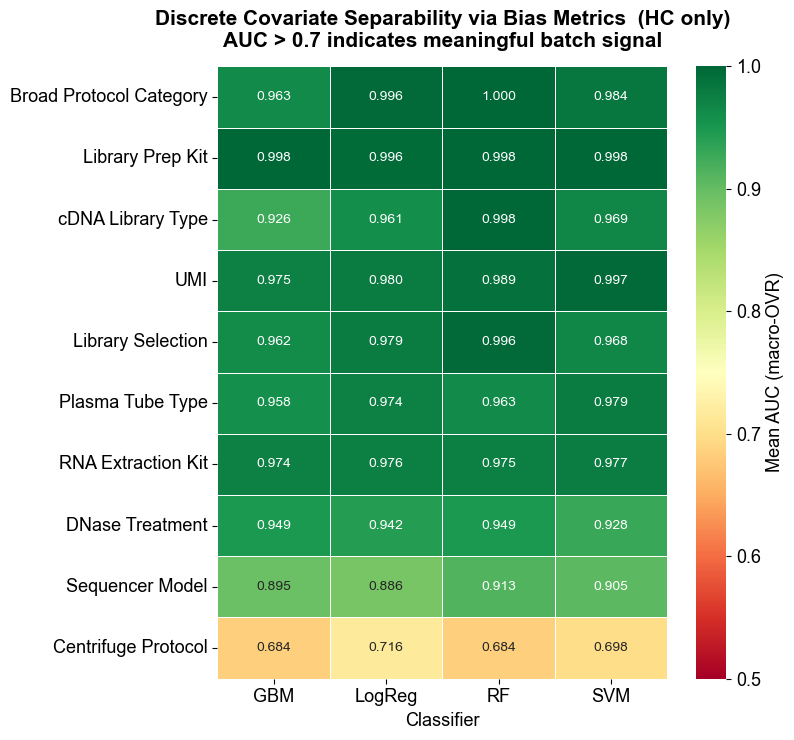

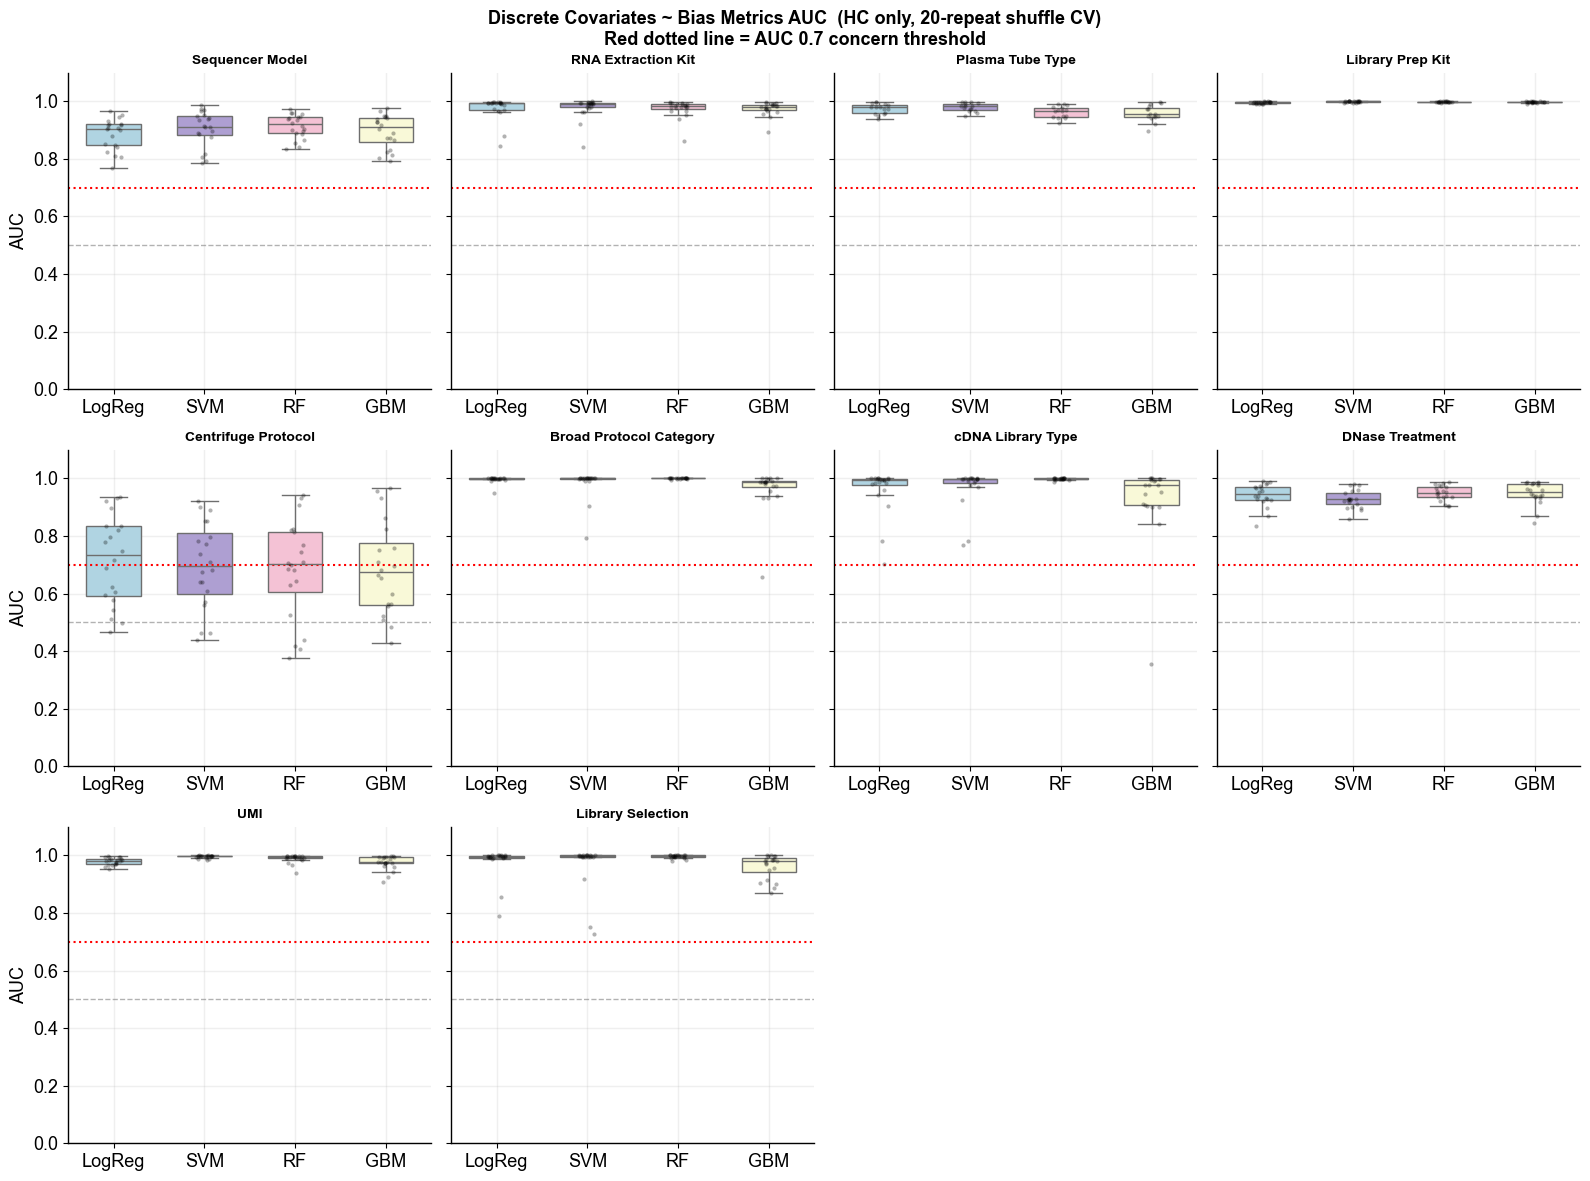

Saved -> Analysis_Results/discrete_covariate_auc/


In [8]:
import os
os.makedirs("./Analysis_Results/BiasBatch/discrete_covariate_auc", exist_ok=True)
DISCRETE_COVARIATES = [
    "instrument",                    
    "rna_extraction_kit_short_name", 
    "plasma_tubes_short_name",       
    "library_prep_kit_short_name",   
    "Centrifuge_Protocol",           
    "broad_protocol_category",       
    "cdna_library_type",            
    "dnase",                         
    "UMI",                           
    "librarylayout",                
    "library_selection",             
]

BIAS_FOR_CLF = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "(NP80/NG80)",
]

print("Running discrete covariate AUC evaluation (HC only, batch-disjoint splits) ...")
df_covar_auc, df_covar_meta = check_discrete_covariate_batch_effects(
    adata,
    bias_list           = BIAS_FOR_CLF,
    covariates          = DISCRETE_COVARIATES,
    hc_label            = "Healthy Control",
    phenotype_col       = "Phenotype_Processed",
    min_class_samples   = 10,
    n_repeats           = 20,
    group_col           = "Batch_ID",
    min_batches_per_class = 2,
)
print(f"\nTotal AUC records: {len(df_covar_auc):,}")

label_map = {
    "Batch_ID":                      "Batch ID (Granular)",
    "instrument":                    "Sequencer Model",
    "rna_extraction_kit_short_name": "RNA Extraction Kit",
    "plasma_tubes_short_name":       "Plasma Tube Type",
    "library_prep_kit_short_name":   "Library Prep Kit",
    "Centrifuge_Protocol":           "Centrifuge Protocol",
    "broad_protocol_category":       "Broad Protocol Category",
    "cdna_library_type":             "cDNA Library Type",
    "dnase":                         "DNase Treatment",
    "UMI":                           "UMI",
    "librarylayout":                 "Library Layout",
    "library_selection":             "Library Selection",
}

auc_pivot = (
    df_covar_auc.groupby(["Covariate", "Model"])["AUC"]
    .agg(mean="mean", std="std")
    .round(3)
    .unstack("Model")
)
auc_pivot.columns = [f"{stat}_{mdl}" for stat, mdl in auc_pivot.columns]
auc_pivot.index   = [label_map.get(c, c) for c in auc_pivot.index]

if not df_covar_meta.empty:
    meta_idx = df_covar_meta.set_index("covariate")
    meta_idx.index = [label_map.get(c, c) for c in meta_idx.index]
    auc_pivot = auc_pivot.join(meta_idx[["n_classes", "n_samples", "n_batches", "n_folds"]], how="left")

mean_cols  = [c for c in auc_pivot.columns if c.startswith("mean_")]
best_auc   = auc_pivot[mean_cols].max(axis=1)
auc_pivot["best_AUC"] = best_auc.round(3)
auc_pivot["concern"]  = best_auc.apply(
    lambda x: "High (>0.8)" if x > 0.8 else ("Moderate (>0.7)" if x > 0.7 else "Low")
)

display_cols = (
    ["n_classes", "n_samples", "n_batches", "n_folds", "best_AUC", "concern"]
    + [c for c in mean_cols]
    + [c for c in auc_pivot.columns if c.startswith("std_")]
)
display_cols = [c for c in display_cols if c in auc_pivot.columns]

print("Discrete Covariate Batch Effect Summary")
display(
    auc_pivot[display_cols]
    .sort_values("best_AUC", ascending=False)
    .rename(columns=lambda c: c.replace("mean_", "μAUC_").replace("std_", "σAUC_"))
)

plot_covariate_auc_heatmap(
    df_covar_auc,
    df_meta   = df_covar_meta,
    save_path = None,  # was "./Analysis_Results/BiasBatch/discrete_covariate_auc/auc_heatmap.png"
)

plot_covariate_auc_violins(
    df_covar_auc,
    n_cols    = 4,
    save_path = None,  # was "./Analysis_Results/BiasBatch/discrete_covariate_auc/auc_violins.png"
)

# auc_pivot.to_csv("./Analysis_Results/BiasBatch/discrete_covariate_auc/summary.csv")
# df_covar_auc.to_csv("./Analysis_Results/BiasBatch/discrete_covariate_auc/auc_raw.csv", index=False)
print("Saved -> Analysis_Results/BiasBatch/discrete_covariate_auc/")